In [1]:
import scanit
import torch
import scanpy as sc
import pandas as pd
import anndata as ad
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [2]:
import os

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['TBB_NUM_THREADS'] = '1'


### Functions

In [3]:
def extract_and_save_cluster_labels(adata, clustering_key, output_file, emb_path):
    
    if clustering_key not in adata.obs.columns:
        raise ValueError(f"Clustering key '{clustering_key}' not found in adata.obs")
    
    cluster_labels = adata.obs[clustering_key]
    
    df = pd.DataFrame({
        'Id': adata.obs_names, #range(len(cluster_labels)),
        'Label': cluster_labels.values
    })
    df['Label'] = df['Label'].astype('int') + 1
    
    df.to_csv(output_file, index=False)
    df_emb = pd.DataFrame(adata.obsm["X_scanit"])
    df_emb.index = adata.obs_names
    df_emb.to_csv(emb_path, index = False)
    
    print(f"Cluster labels saved to {output_file}")
    
    print(df.head().to_string(index=False))

### Reading files

(1950, 32285)
Epoch: 000, Loss: 1.4057
Epoch: 500, Loss: 0.0005
Epoch: 999, Loss: 0.0002
Epoch: 000, Loss: 1.3968
Epoch: 500, Loss: 0.0007
Epoch: 999, Loss: 0.0061
Epoch: 000, Loss: 1.4034
Epoch: 500, Loss: 0.0005
Epoch: 999, Loss: 0.0002


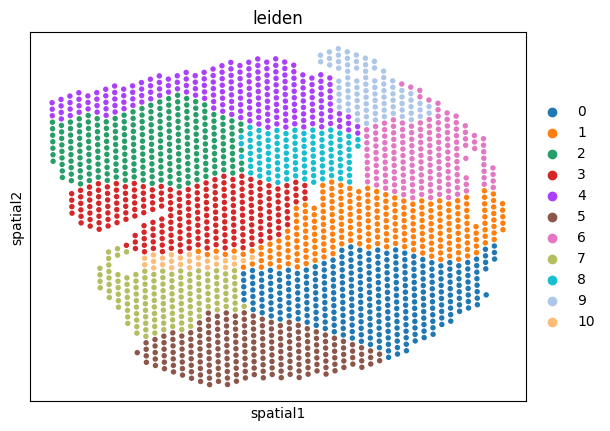

Cluster labels saved to /data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/final_domain_outputs//output_SCANIT.csv
                 Id  Label
AAACAAGTATCTCCCA-13      7
AAACAGAGCGACTCCT-13      3
AAACCCGAACGAAATC-13     10
AAACCGGGTAGGTACC-13      6
AAACCGTTCGTCCAGG-13      1


In [4]:

method_name = "SCANIT"
path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/mouse_breast_cancer.h5ad"

results_path = "/data/Ajita/Spatial/Datasets/Spatial_Domain/Real_datasets/mouse_breast_cancer/final_domain_outputs/" 

adata = sc.read_h5ad(path)
print (adata.shape)

adata_sp = adata.copy()
sc.pp.normalize_total(adata_sp)

sc.pp.log1p(adata_sp)
sc.pp.scale(adata_sp)

scanit.tl.spatial_graph(adata_sp, method='knn', alpha_n_layer=3, knn_n_neighbors=10)
scanit.tl.spatial_representation(adata_sp, n_h=30, n_epoch=1000, lr=0.001, device='cuda', n_consensus=3, projection='umap', 
    python_seed=0, torch_seed=0, numpy_seed=0)

leiden_res = 0.13
nn = 25
sc.pp.neighbors(adata_sp, use_rep='X_scanit', n_neighbors=nn, random_state=42)
sc.tl.leiden(adata_sp, resolution=leiden_res, random_state=42)
#sc.pl.spatial(adata_sp, spot_size=20, color='leiden', frameon=True, palette='tab20')
sc.pl.embedding(adata_sp, basis = "spatial", color = "leiden")

extract_and_save_cluster_labels(adata_sp, 'leiden', results_path + "/output_" + method_name + ".csv", results_path + "/embedding_" + \
                               method_name + ".csv")

    